<a href="https://colab.research.google.com/github/Typicalanne/Typicalanne/blob/main/Medical_Aid_Pricing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A Medical Aid Pricing Model for South Africa**

## **Objective**
######To develop a predictive model that estimates medical aid costs based on customer lifestyle and geographica region

## **Analysis Plan**

###### 1. Evaluate Dataset Suitability
- Check structure, nulls, and data types
- Assess distribution of target variable

###### 2. Exploratory Data Analysis (EDA)
- Visualize distributions
- Look at feature relationships

###### 3. Preprocessing & Feature Selection
- Encode categorical variables

###### 4. Model Training
- Split data
- Train linear regression model
- Calculate RMSE and $R^2$

###### 5. Evaluation
- Residual analysis

###### 6. Retraining the Model
- Log transformation
- Interaction terms
- Ridge regression

###### 7. Reporting
- Summarize findings and recommendations using word

## **1. Evaluating Dataset Suitability**

In [ ]:
import pandas as pd

#loading the dataset
file_path="/content/drive/MyDrive/Colab Notebooks/Programming/insurance.csv"
df=pd.read_csv(file_path)

#summary statistics and info
summary = df.describe(include="all")
info = df.info()

#check for missing values
missing_values = df.isnull().sum()

#displaying a few raws to see the structure
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


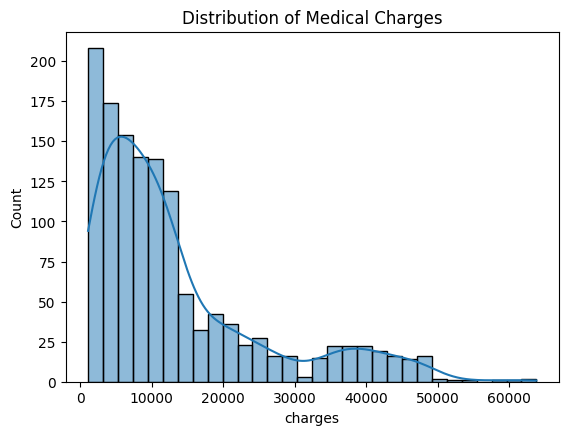

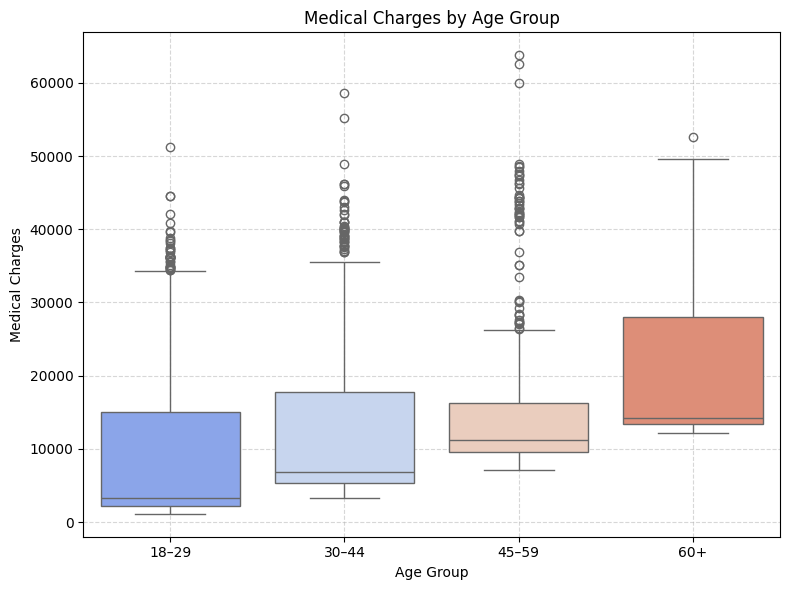

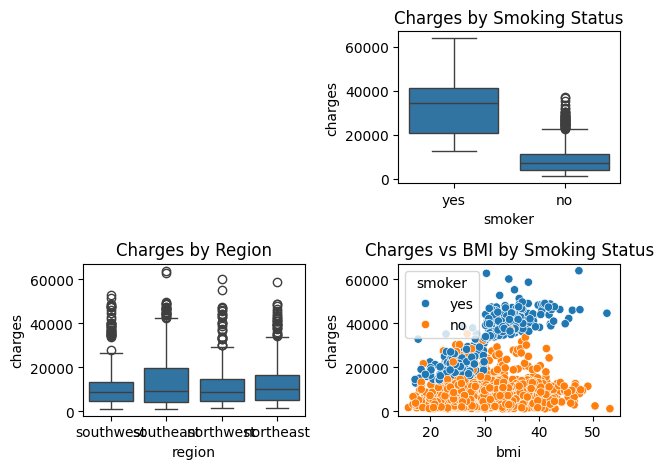

(                age   sex          bmi     children smoker     region  \
 count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
 unique          NaN     2          NaN          NaN      2          4   
 top             NaN  male          NaN          NaN     no  southeast   
 freq            NaN   676          NaN          NaN   1064        364   
 mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
 std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
 min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
 25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
 50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
 75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
 max       64.000000   NaN    53.130000     5.000000    NaN        NaN   
 
              charges  
 count    1338.000000  
 unique           NaN  
 top              NaN  
 freq         

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#visualizations for EDA
plt.figure(figsize=(14, 10))

#distribution of charges
plt.subplot(2, 2, 1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Medical Charges')

#create age bins and labels
bins = [17, 29, 44, 59, 65]
labels = ['18–29', '30–44', '45–59', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

#create the boxplot with hue set to x (age_group) and legend turned off
plt.figure(figsize=(8, 6))
sns.boxplot(x='age_group', y='charges', hue='age_group', data=df, palette='coolwarm', legend=False)
plt.title('Medical Charges by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Medical Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#boxplot of charges by smoker
plt.subplot(2, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')

#boxplot of charges by region
plt.subplot(2, 2, 3)
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')

#pairplot for numeric features
plt.subplot(2, 2, 4)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI by Smoking Status')

plt.tight_layout()
plt.show()

summary, missing_values


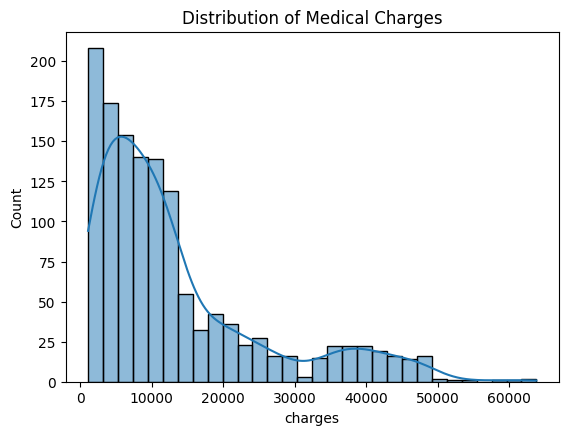

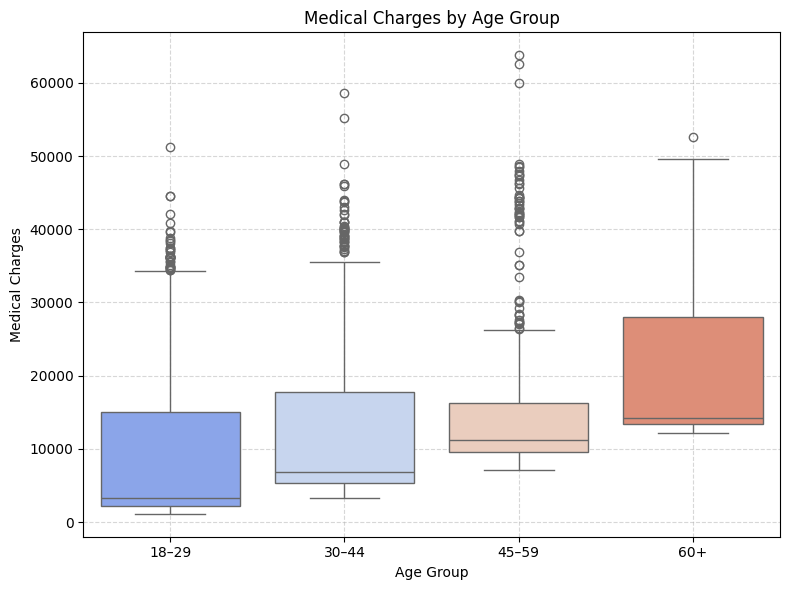

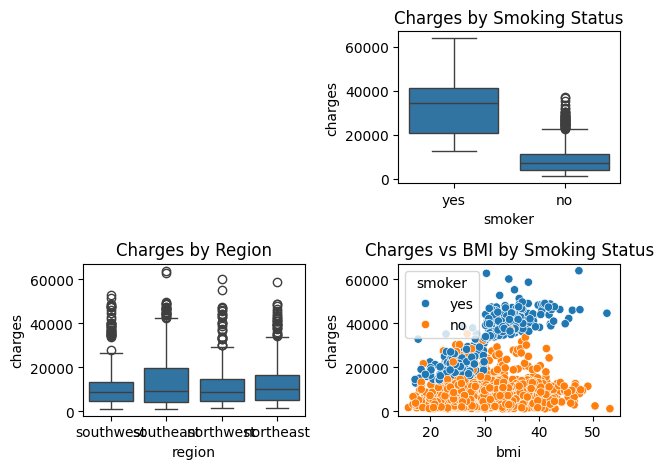

(                age   sex          bmi     children smoker     region  \
 count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
 unique          NaN     2          NaN          NaN      2          4   
 top             NaN  male          NaN          NaN     no  southeast   
 freq            NaN   676          NaN          NaN   1064        364   
 mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
 std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
 min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
 25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
 50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
 75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
 max       64.000000   NaN    53.130000     5.000000    NaN        NaN   
 
              charges  
 count    1338.000000  
 unique           NaN  
 top              NaN  
 freq         

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#visualizations for EDA
plt.figure(figsize=(14, 10))

#distribution of charges
plt.subplot(2, 2, 1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Medical Charges')

#create age bins and labels
bins = [17, 29, 44, 59, 65]
labels = ['18–29', '30–44', '45–59', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

#create the boxplot with hue set to x (age_group) and legend turned off
plt.figure(figsize=(8, 6))
sns.boxplot(x='age_group', y='charges', hue='age_group', data=df, palette='coolwarm', legend=False)
plt.title('Medical Charges by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Medical Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#boxplot of charges by smoker
plt.subplot(2, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')

#boxplot of charges by region
plt.subplot(2, 2, 3)
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')

#pairplot for numeric features
plt.subplot(2, 2, 4)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI by Smoking Status')

plt.tight_layout()
plt.show()

summary, missing_values


###### **Data structure**
- Dataset Size: 1,338 records

- Target Varibles: 'charges' (annual medical aid cost)

- Features: 'age' (numeric), 'sex' (categorical), 'bmi' (numeric), 'children' (numeric), 'smoker' (categorical), 'region' (categprical)

###### **Data quality**
- No missing values
- Balanced categories
- Suitable for regression

# **2. Exploratory Data Analysis**

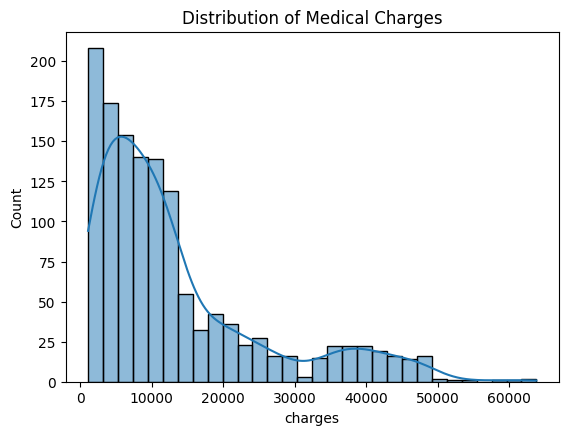

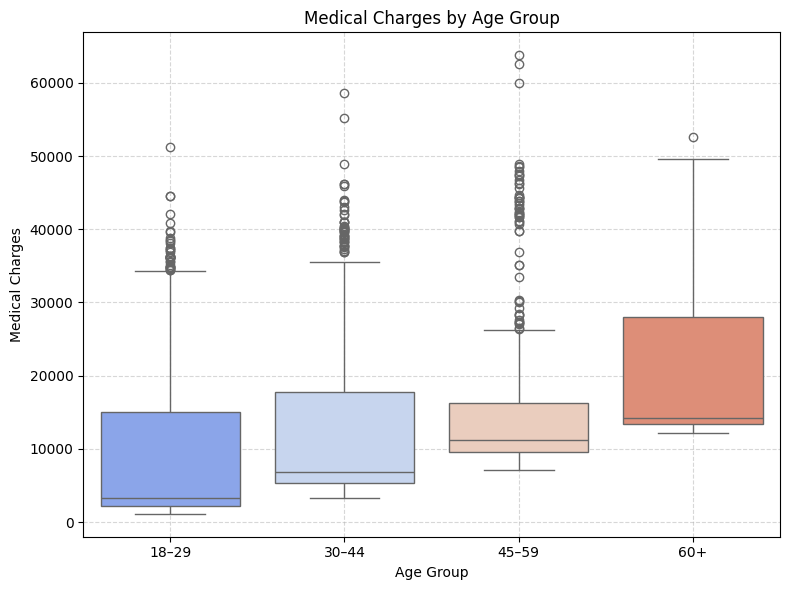

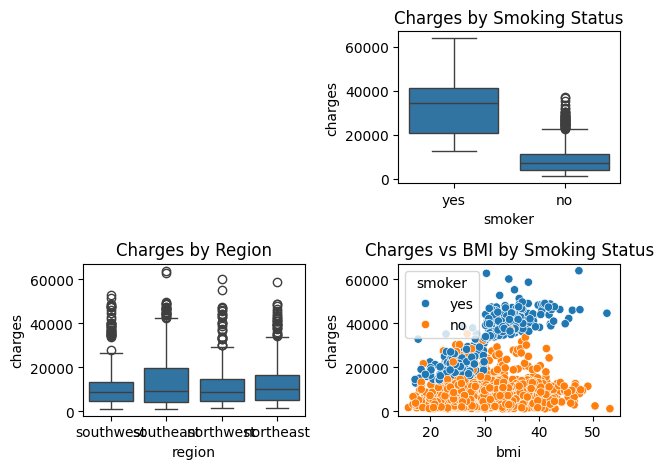

(                age   sex          bmi     children smoker     region  \
 count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
 unique          NaN     2          NaN          NaN      2          4   
 top             NaN  male          NaN          NaN     no  southeast   
 freq            NaN   676          NaN          NaN   1064        364   
 mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
 std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
 min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
 25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
 50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
 75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
 max       64.000000   NaN    53.130000     5.000000    NaN        NaN   
 
              charges  
 count    1338.000000  
 unique           NaN  
 top              NaN  
 freq         

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#visualizations for EDA
plt.figure(figsize=(14, 10))

#distribution of charges
plt.subplot(2, 2, 1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Medical Charges')

#create age bins and labels
bins = [17, 29, 44, 59, 65]
labels = ['18–29', '30–44', '45–59', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

#create the boxplot with hue set to x (age_group) and legend turned off
plt.figure(figsize=(8, 6))
sns.boxplot(x='age_group', y='charges', hue='age_group', data=df, palette='coolwarm', legend=False)
plt.title('Medical Charges by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Medical Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#boxplot of charges by smoker
plt.subplot(2, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')

#boxplot of charges by region
plt.subplot(2, 2, 3)
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')

#pairplot for numeric features
plt.subplot(2, 2, 4)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI by Smoking Status')

plt.tight_layout()
plt.show()

summary, missing_values



###### **Distributions**
- charges are right-skewed, influenced by high-cost outliers.
- Smokers have significantly higher charges than non-smokers.
- Higher bmi especially for smokers tends to correspond with higher costs.

###### **Visual Insights**
- Boxplots and scatter plots show strong patterns:
  - smoker: clear cost difference
  - bmi & smoker: visible interaction
  - region: some cost variation
  - age: moderate positive correlation with charges

# **3. Preprocessing and Feature Selection**
###### Categorical variables will be encoded using one-hot encoding (dropping first to avoid multicollinearity) and a pipeline will be built using ColumnTransformer and LinearRegression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#define features and target
X = df.drop('charges', axis=1)
y = df['charges']

#categorical and numerical features
categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children']

#preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  #pass numerical features without change
)

###### **Encoding data**
- One-hot encoding applied to:
  - sex
  - smoker
  - region
- Numerical features used as-is:
  - age, bmi, children

## **4. Model Training**
Dataset is split into training (80%) and testing (20%) sets and the model will be trained using standard Linear Regression.
###### **Building pipeline with Linear Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Age Group Feature Engineering
bins = [17, 29, 44, 59, 65]
labels = ['18–29', '30–44', '45–59', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# 2. Define target and features
X = df.drop(columns=['charges'])  # Or use 'log_charges' if modeling transformed target
y = df['charges']

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Define column types
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region', 'age_group']

# 5. Preprocessing: scaling numeric + one-hot encoding categorical
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# 6. Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 7. Train the model
model_pipeline.fit(X_train, y_train)

# 8. Predict
y_pred = model_pipeline.predict(X_test)

# 9. Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Results")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")


Linear Regression Results
RMSE: 5750.53
R² Score: 0.787


###### **Results**
RMSE (Root Mean Squared Error): $5,750.53

- There is an average prediction error of %5,750.53 in currency terms.

$R^2$ Score: 0.787

- About 78.4% of the variance in medical charges is explained by the model

## **5. Evaluation**

###### For this regression model, we want metrics which reflect error magnitude in actual cost units, explained variance to judge predictive power and fair comparison across models. To achieve this we will use the following:

###### Root Mean Squared Error (RMSE)
   - Expressed in the same units as the target (charges), so it's business-friendly.
   - Sensitive to outliers, which is useful here, since high medical costs are important. We want to understand how far off, on average, the model's predictions are in real-world units.
   
###### $R^2$ Score (Coefficient of Determination)
   - Tells us how much of the variation in medical costs is captured by the model.
We want to know how useful this model is for explaining medical cost behavior.

#### **Residual analysis**
The analysis will help show how well the model fits the data, if there are outliers or patterns in the errors and wether any assumptions of linear regression are violated.

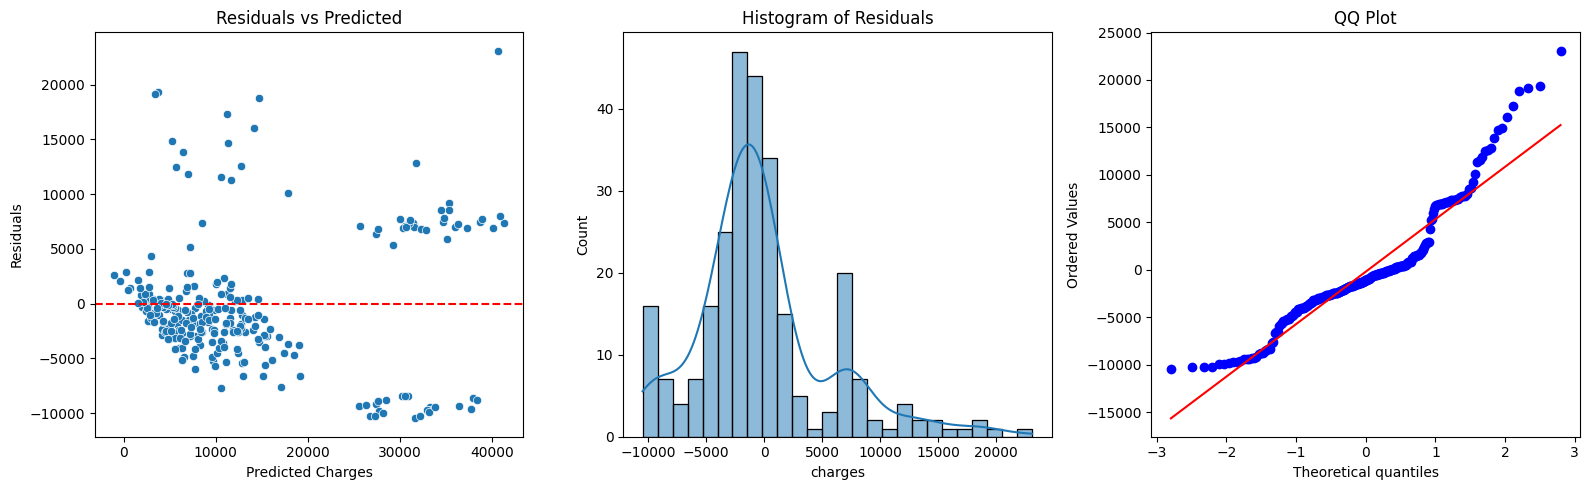

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

#calculate residuals
residuals = y_test - y_pred

#set up plots
plt.figure(figsize=(16, 5))

# 1. residuals vs Predicted
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')

# 2. histogram of residuals
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')

# 3. QQ plot
plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot')

plt.tight_layout()
plt.show()


####**Results & Interpretations**
###### **Residue vs Predicted**
- strong downward trend meaning residuals are highly negative and increase in magnitude with larger predicted values
- This pattern indicates model underfitting and non-linearity meaning the model is consistently underestimating charges for higher predicted values.

######**Histogram of residuals**
- strong right-skewed
- Residuals are not normally distributed, which violates a key assumption of linear regression.

######**QQ plot**
- Deviates from the red line at both tail
- Confirms that residuals are not normally distributed


##**6. Retraining the Model**

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

#adding interaction feature: bmi × smoker
df['bmi_smoker_interaction'] = df['bmi'] * df['smoker'].map({'yes': 1, 'no': 0})

#new target variable (log-transformed charges)
df['log_charges'] = np.log(df['charges'])

#features and transformed target
X = df.drop(['charges', 'log_charges'], axis=1)
y = df['log_charges']

#categorical and numerical features
categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children', 'bmi_smoker_interaction']

#updated preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)])

#ridge Regression with cross-validated alpha
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)

#final pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', ridge_model)])

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#fitting model
ridge_pipeline.fit(X_train, y_train)

#predicting on test set (log scale)
y_pred_log = ridge_pipeline.predict(X_test)

#converting predictions back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

#evaluation
rmse_new = np.sqrt(mean_squared_error(y_true, y_pred))
r2_new = r2_score(y_true, y_pred)


print(f"RMSE: {rmse_new:.2f}")
print(f"R² Score: {r2_new:.3f}")
print(f"Best Alpha (Ridge Regularization Strength): {ridge_model.alpha_:.4f}")


RMSE: 8262.38
R² Score: 0.560
Best Alpha (Ridge Regularization Strength): 8.2864


#####**Results**
######**RMSE** score: $8262.38
- it is slightly higher

######**$R^2$** score: 0.560
- it is slightly lower explained variance

######**Best Alpha**: 8.2864

######**Interpretation**
- RMSE means on average, the model prediction deviates by $8,262.38 from actual values and is significantly higher that 5,663 resulting to lower accuracy

- $R^2$ score	means the model explains 56% of the variability in medical charges which is also much lower than the 79.3% explained by Lasso, indicating reduced explanatory power.
- Best Alpha Best score shows the chosen regularization strength. A high alpha means the model applied strong penalties, which likely oversimplified the model and hurt performance.



### **7. Re-running Residual Analysis**
####**Visual Comparison**

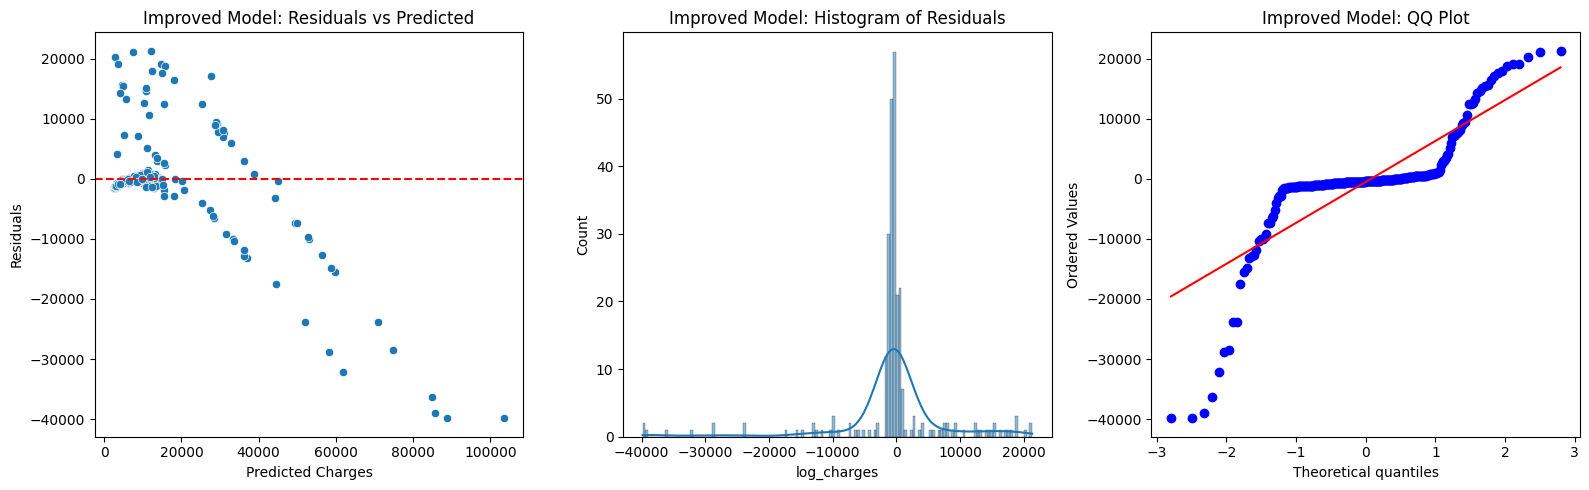

In [ ]:
#residual analysis for improved model (Ridge with log-transformed target)

#residuals on original scale
residuals_improved = y_true - y_pred  # true and predicted already exponentiated

#plot residuals
plt.figure(figsize=(16, 5))

# 1. residuals vs Predicted
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred, y=residuals_improved)
plt.axhline(0, color='red', linestyle='--')
plt.title('Improved Model: Residuals vs Predicted')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')

# 2. histogram of residuals
plt.subplot(1, 3, 2)
sns.histplot(residuals_improved, kde=True)
plt.title('Improved Model: Histogram of Residuals')

# 3. QQ plot
plt.subplot(1, 3, 3)
stats.probplot(residuals_improved, dist="norm", plot=plt)
plt.title('Improved Model: QQ Plot')

plt.tight_layout()
plt.show()

###**Results & Interpretation**
 ###### **1.Residuals vs Predicted**
- Residuals are more tightly clustered around zero.
- Still a curved pattern (especially for lower predicted values), but it's less extreme than before.
- This suggests reduced bias and a better fit overall. The curve implies some nonlinearity still remains and a linear model might not fully capture the relationships

######**2. Histogram of Residuals**
- The residuals are now more centered around zero and resemble a normal distribution more closely.
- The residual distribution has significantly improved suggesting fewer systematic errors and better assumptions for inference. Some outliers are still present, but the model is less skewed than before.

######**3. QQ Plot**
- Points are closer to the red line, especially in the center and deviations still exist at both tails.
- The residuals are more normally distributed, especially in the middle range of predicted values. There are still some violations at the extremes but overall, the distribution is more aligned with normality than before.